# 📊 Agricultural Data Exploration
## India Data Portal - Comprehensive Dataset Analysis

This notebook provides a systematic exploration of all 22 datasets covering:
- **Price Data**: Retail, wholesale, MSP, cost of cultivation
- **Climate Data**: Rainfall, groundwater, vulnerability indicators
- **Agriculture Production**: Crop census, horticulture
- **Exports**: Regional export data to 5 continents

In [2]:
# Required Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Data path
DATA_PATH = Path('../data/raw/')
print(f"Data directory: {DATA_PATH.absolute()}")

Data directory: c:\Users\Asus\OneDrive\Documents\Project-2\notebooks\..\data\raw


## 1. Dataset Inventory & Overview

In [3]:
# List all datasets with file sizes
import os

def get_file_size_mb(filepath):
    return os.path.getsize(filepath) / (1024 * 1024)

datasets_info = []
for file in sorted(DATA_PATH.glob('*.csv')):
    size_mb = get_file_size_mb(file)
    datasets_info.append({
        'filename': file.name,
        'size_mb': round(size_mb, 2),
        'category': 'Large' if size_mb > 100 else 'Medium' if size_mb > 10 else 'Small'
    })

inventory_df = pd.DataFrame(datasets_info)
print(f"Total datasets: {len(inventory_df)}")
print(f"Total size: {inventory_df['size_mb'].sum():.1f} MB")
print("\nDataset Inventory:")
display(inventory_df)

Total datasets: 21
Total size: 3697.0 MB

Dataset Inventory:


,filename,size_mb,category
0,area-and-production-statistics-nhb.csv,0.08,Small
1,cgwb-changes-in-depth-to-water-level.csv,75.41,Medium
2,climate-vulnerability-indicators-district-wise...,0.20,Small
3,climate-vulnerability-indicators-state-wise.csv,0.01,Small
4,consumer-price-index (1).csv,21.72,Medium
5,cost-of-cultivation.csv,1.68,Small
6,daily-rainfall-at-state-level.csv,11.97,Medium
7,daily-rainfall-data-district-level.csv,266.35,Large
8,daily-retail-prices-of-essential-commodities.csv,119.20,Large
9,district-level-agcensus-crop.csv,218.91,Large


## 2. Quick Load Functions
Since some files are very large (900MB+), we provide options to sample data

In [4]:
def load_dataset(filename, nrows=None, sample_frac=None, parse_dates=None):
    """Load a dataset with optional sampling for large files."""
    filepath = DATA_PATH / filename
    
    if nrows:
        df = pd.read_csv(filepath, nrows=nrows, parse_dates=parse_dates)
        print(f"Loaded first {nrows:,} rows from {filename}")
    elif sample_frac:
        df = pd.read_csv(filepath, parse_dates=parse_dates)
        df = df.sample(frac=sample_frac, random_state=42)
        print(f"Loaded {len(df):,} rows ({sample_frac*100}% sample) from {filename}")
    else:
        df = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {len(df):,} rows from {filename}")
    
    return df

def dataset_summary(df, name="Dataset"):
    """Generate a comprehensive summary of a dataset."""
    print(f"\n{'='*60}")
    print(f"📊 {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nData Types:")
    print(df.dtypes.value_counts())
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({'missing': missing, 'percent': missing_pct})
    print(missing_df[missing_df['missing'] > 0])
    print(f"\nSample Data:")
    display(df.head())
    return df

---
## 3. PRICE DATA EXPLORATION

### 3.1 Minimum Support Prices (MSP)

In [5]:
# MSP is small - load fully
msp = load_dataset('minimum-support-prices.csv')
dataset_summary(msp, 'Minimum Support Prices')

Loaded 737 rows from minimum-support-prices.csv

📊 Minimum Support Prices
Shape: 737 rows × 5 columns

Columns: ['id', 'year', 'crop', 'season', 'min_support_price']

Data Types:
object     3
int64      1
float64    1
Name: count, dtype: int64

Missing Values:
                   missing  percent
min_support_price        1      0.1

Sample Data:


,id,year,crop,season,min_support_price
0,0,2022-2023,Paddy - Common,Kharif,2040.0
1,1,2022-2023,Paddy - Grade 'A',Kharif,2060.0
2,2,2022-2023,Jowar - Hybrid,Kharif,2970.0
3,3,2022-2023,Jowar - Maldandi,Kharif,2990.0
4,4,2022-2023,Bajra,Kharif,2350.0


,id,year,crop,season,min_support_price
0,0,2022-2023,Paddy - Common,Kharif,2040.0
1,1,2022-2023,Paddy - Grade 'A',Kharif,2060.0
2,2,2022-2023,Jowar - Hybrid,Kharif,2970.0
3,3,2022-2023,Jowar - Maldandi,Kharif,2990.0
4,4,2022-2023,Bajra,Kharif,2350.0
...,...,...,...,...,...
732,732,1998-1999,Copra - Ball,Others,3125.0
733,733,1998-1999,Jute,Others,650.0
734,734,1998-1999,Sugarcane,Others,52.7
735,735,1998-1999,Tobacco - Black Soil (F2 Gr),Others,22.5


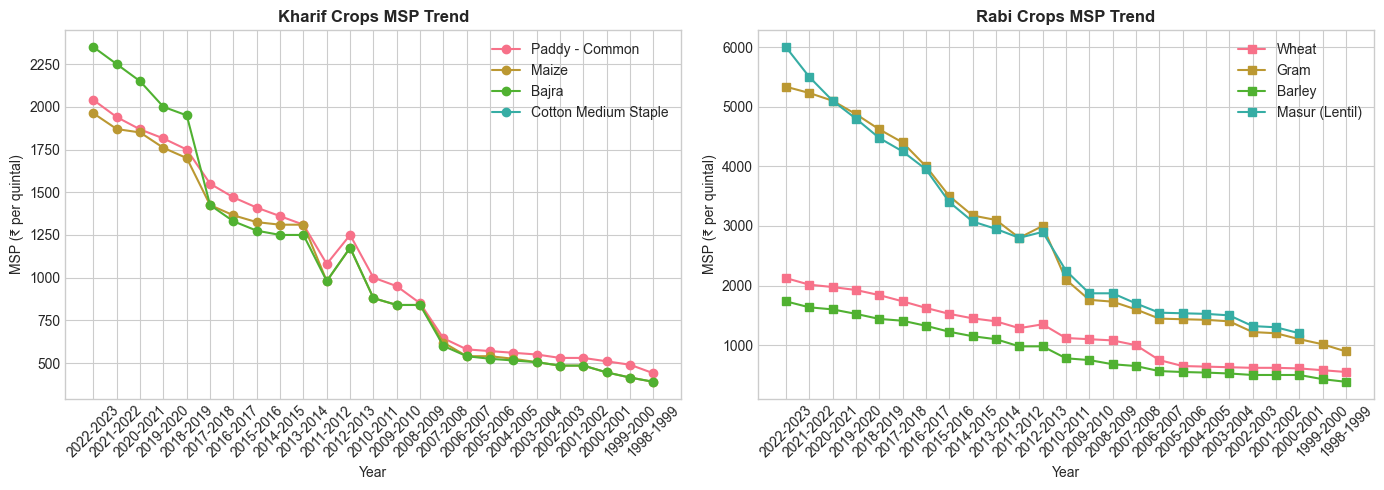

In [6]:
# MSP trends visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kharif crops MSP trend
kharif = msp[msp['season'] == 'Kharif'].copy()
major_crops = ['Paddy - Common', 'Maize', 'Bajra', 'Cotton Medium Staple']
kharif_major = kharif[kharif['crop'].isin(major_crops)]

for crop in major_crops:
    crop_data = kharif_major[kharif_major['crop'] == crop]
    axes[0].plot(crop_data['year'], crop_data['min_support_price'], marker='o', label=crop)

axes[0].set_title('Kharif Crops MSP Trend', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('MSP (₹ per quintal)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Rabi crops
rabi = msp[msp['season'] == 'Rabi'].copy()
rabi_crops = ['Wheat', 'Gram', 'Barley', 'Masur (Lentil)']
rabi_major = rabi[rabi['crop'].isin(rabi_crops)]

for crop in rabi_crops:
    crop_data = rabi_major[rabi_major['crop'] == crop]
    axes[1].plot(crop_data['year'], crop_data['min_support_price'], marker='s', label=crop)

axes[1].set_title('Rabi Crops MSP Trend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('MSP (₹ per quintal)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visualizations/msp_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Cost of Cultivation

In [7]:
coc = load_dataset('cost-of-cultivation.csv')
dataset_summary(coc, 'Cost of Cultivation')

Loaded 3,880 rows from cost-of-cultivation.csv

📊 Cost of Cultivation
Shape: 3,880 rows × 66 columns

Columns: ['id', 'year', 'state_name', 'state_code', 'crop_name', 'crop_code', 'crop_type', 'cul_cost_a1', 'cul_cost_a2', 'cul_cost_b1', 'cul_cost_b2', 'cul_cost_c1', 'cul_cost_c2', 'cul_cost_c2rev', 'cul_cost_a2fl', 'prod_cost_a1', 'prod_cost_a2', 'prod_cost_b1', 'prod_cost_b2', 'prod_cost_c1', 'prod_cost_c2', 'prod_cost_c2rev', 'prod_cost_c3', 'prod_cost_a2fl', 'main_product_value', 'by_product_value', 'mat_lab_input_seed', 'mat_lab_input_fertilizer', 'mat_lab_input_manure', 'mat_lab_input_hmn_lab', 'mat_lab_input_ani_lab', 'seed_rate_per_unit', 'fert_rate_per_unit', 'manure_rate_per_unit', 'hmn_lab_rate_per_unit', 'ani_lab_rate_per_unit', 'implicit_rate', 'num_holdings_sample', 'num_tehsils_sample', 'derived_yield', 'hmn_lab_hrs_family', 'hmn_lab_hrs_attached', 'hmn_lab_hrs_casual', 'opr_cost_hmn_lab_family', 'opr_cost_hmn_lab_attached', 'opr_cost_hmn_lab_casual', 'opr_cost_ani_lab_h

,id,year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,cul_cost_a2,cul_cost_b1,cul_cost_b2,cul_cost_c1,cul_cost_c2,cul_cost_c2rev,cul_cost_a2fl,prod_cost_a1,prod_cost_a2,prod_cost_b1,prod_cost_b2,prod_cost_c1,prod_cost_c2,prod_cost_c2rev,prod_cost_c3,prod_cost_a2fl,main_product_value,...,hmn_lab_hrs_attached,hmn_lab_hrs_casual,opr_cost_hmn_lab_family,opr_cost_hmn_lab_attached,opr_cost_hmn_lab_casual,opr_cost_ani_lab_hired,opr_cost_ani_lab_owned,opr_cost_mch_lab_hired,opr_cost_mch_lab_owned,opr_cost_seed,opr_cost_fertilizer,opr_cost_manure,opr_cost_insecticides,opr_cost_irrigation_chrg,opr_cost_misc,opr_cost_interest_on_wrk_cap,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,opr_cost_contractor_pay
0,0,2018-19,Andhra Pradesh,28,Tur (Arhar),202,Pulses,25062.60,25062.60,26029.29,36410.62,29874.23,40255.56,40467.12,NaN,3394.86,3394.86,3503.11,4998.98,3860.09,5355.96,5384.11,5922.52,NaN,33426.65,...,0.00,181.81,3844.94,0.00,9007.08,1889.40,36.84,2200.03,4592.92,1214.14,1910.54,1363.99,1852.44,1.34,132.46,756.27,28802.40,10381.33,0.00,0.00,105.13,966.70,11453.16,0.0,NaN
1,1,2018-19,Bihar,10,Tur (Arhar),202,Pulses,14717.68,14717.68,15477.71,31064.38,21925.03,37511.70,37593.97,NaN,1321.95,1321.95,1390.21,2790.21,1969.31,3369.31,3376.70,3714.37,NaN,42133.33,...,0.00,92.91,6447.32,0.00,4333.33,0.00,0.00,5000.00,0.00,2133.33,2166.68,0.00,0.00,0.00,0.00,426.04,20506.70,15586.67,0.00,240.00,418.30,760.03,17005.00,0.0,NaN
2,2,2018-19,Chhattisgarh,22,Tur (Arhar),202,Pulses,14183.54,14183.54,14528.70,21017.09,19288.78,25777.16,26196.39,NaN,2498.48,2498.48,2560.47,3685.68,3410.55,4535.75,4609.52,5070.47,NaN,23032.27,...,0.00,137.32,4760.07,0.00,3812.44,898.71,0.00,5799.65,0.00,1764.97,1129.43,0.00,0.00,0.00,20.79,419.55,18605.61,6488.38,0.00,1.64,336.36,345.17,7171.55,0.0,NaN
3,3,2018-19,Gujarat,24,Tur (Arhar),202,Pulses,27435.91,28655.86,29853.94,38062.27,40984.93,49193.26,51900.29,NaN,3407.99,3558.47,3687.22,4694.23,5055.93,6062.94,6397.20,7036.92,NaN,41355.52,...,3.19,339.04,11131.00,97.50,7908.66,329.29,5105.53,4979.45,1254.21,1031.58,982.42,1291.79,1406.23,1577.96,332.97,821.79,38250.38,6988.38,1219.96,17.95,298.56,2418.03,10942.88,0.0,NaN
4,4,2018-19,Karnataka,29,Tur (Arhar),202,Pulses,25298.57,25298.57,26711.34,36388.74,31141.20,40818.60,43856.18,NaN,3346.24,3346.24,3540.41,4786.38,4109.20,5355.16,5753.67,6329.04,NaN,37937.97,...,0.00,210.80,4429.86,45.76,4541.48,2458.03,4246.57,5783.81,417.48,857.31,2697.88,499.83,2475.79,111.98,151.06,758.96,29475.80,9677.40,0.00,10.82,241.81,1412.77,11342.80,0.0,NaN


,id,year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,cul_cost_a2,cul_cost_b1,cul_cost_b2,cul_cost_c1,cul_cost_c2,cul_cost_c2rev,cul_cost_a2fl,prod_cost_a1,prod_cost_a2,prod_cost_b1,prod_cost_b2,prod_cost_c1,prod_cost_c2,prod_cost_c2rev,prod_cost_c3,prod_cost_a2fl,main_product_value,...,hmn_lab_hrs_attached,hmn_lab_hrs_casual,opr_cost_hmn_lab_family,opr_cost_hmn_lab_attached,opr_cost_hmn_lab_casual,opr_cost_ani_lab_hired,opr_cost_ani_lab_owned,opr_cost_mch_lab_hired,opr_cost_mch_lab_owned,opr_cost_seed,opr_cost_fertilizer,opr_cost_manure,opr_cost_insecticides,opr_cost_irrigation_chrg,opr_cost_misc,opr_cost_interest_on_wrk_cap,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,opr_cost_contractor_pay
0,0,2018-19,Andhra Pradesh,28,Tur (Arhar),202,Pulses,25062.60,25062.60,26029.29,36410.62,29874.23,40255.56,40467.12,NaN,3394.86,3394.86,3503.11,4998.98,3860.09,5355.96,5384.11,5922.52,NaN,33426.65,...,0.00,181.81,3844.94,0.00,9007.08,1889.40,36.84,2200.03,4592.92,1214.14,1910.54,1363.99,1852.44,1.34,132.46,756.27,28802.40,10381.33,0.00,0.00,105.13,966.70,11453.16,0.0,NaN
1,1,2018-19,Bihar,10,Tur (Arhar),202,Pulses,14717.68,14717.68,15477.71,31064.38,21925.03,37511.70,37593.97,NaN,1321.95,1321.95,1390.21,2790.21,1969.31,3369.31,3376.70,3714.37,NaN,42133.33,...,0.00,92.91,6447.32,0.00,4333.33,0.00,0.00,5000.00,0.00,2133.33,2166.68,0.00,0.00,0.00,0.00,426.04,20506.70,15586.67,0.00,240.00,418.30,760.03,17005.00,0.0,NaN
2,2,2018-19,Chhattisgarh,22,Tur (Arhar),202,Pulses,14183.54,14183.54,14528.70,21017.09,19288.78,25777.16,26196.39,NaN,2498.48,2498.48,2560.47,3685.68,3410.55,4535.75,4609.52,5070.47,NaN,23032.27,...,0.00,137.32,4760.07,0.00,3812.44,898.71,0.00,5799.65,0.00,1764.97,1129.43,0.00,0.00,0.00,20.79,419.55,18605.61,6488.38,0.00,1.64,336.36,345.17,7171.55,0.0,NaN
3,3,2018-19,Gujarat,24,Tur (Arhar),202,Pulses,27435.91,28655.86,29853.94,38062.27,40984.93,49193.26,51900.29,NaN,3407.99,3558.47,3687.22,4694.23,5055.93,6062.94,6397.20,7036.92,NaN,41355.52,...,3.19,339.04,11131.00,97.50,7908.66,329.29,5105.53,4979.45,1254.21,1031.58,982.42,1291.79,1406.23,1577.96,332.97,821.79,38250.38,6988.38,1219.96,17.95,298.56,2418.03,10942.88,0.0,NaN
4,4,2018-19,Karnataka,29,Tur (Arhar),202,Pulses,25298.57,25298.57,26711.34,36388.74,31141.20,40818.60,43856.18,NaN,3346.24,3346.24,3540.41,4786.38,4109.20,5355.16,5753.67,6329.04,NaN,37937.97,...,0.00,210.80,4429.86,45.76,4541.48,2458.03,4246.57,5783.81,417.48,857.31,2697.88,499.83,2475.79,111.98,151.06,758.96,29475.80,9677.40,0.00,10.82,241.81,1412.77,11342.80,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3875,3875,2003-04,Tamil Nadu,33,Sugarcane,401,Sugar,34589.53,35306.99,39628.27,53146.01,43359.49,56877.23,57279.61,NaN,38.95,39.84,44.48,59.54,48.64,63.71,65.20,71.71,NaN,66606.12,...,0.00,0.00,3731.22,2881.74,16337.83,214.45,18.06,766.52,125.22,2925.22,4479.80,781.43,149.38,3202.59,0.00,1992.63,37606.09,12800.27,717.47,73.95,640.70,5038.75,19271.14,NaN,NaN
3876,3876,2003-04,Tamil Nadu,33,Paddy,101,Cereals,18997.47,19208.51,20446.91,27291.31,22987.54,29831.95,29956.83,NaN,379.76,383.09,408.64,544.81,459.55,595.73,598.26,658.09,NaN,27676.99,...,0.00,0.00,2540.63,137.34,6393.18,305.23,245.95,2963.15,162.91,2395.63,2429.22,785.67,406.68,1687.02,14.96,560.22,21027.79,6633.37,211.04,101.32,409.00,1449.43,8804.16,NaN,NaN
3877,3877,2003-04,Tamil Nadu,33,Sesamum (Til),1003,Oilseeds,6838.61,6838.61,8678.45,13114.86,11054.51,15490.92,15490.92,NaN,1201.58,1201.58,1504.07,2249.81,1909.20,2654.94,2654.96,2920.43,NaN,14670.79,...,0.00,0.00,2376.06,118.81,2612.23,155.50,421.22,1161.04,9.40,252.47,718.86,44.31,78.58,769.22,0.00,198.18,8915.88,4436.41,0.00,62.36,236.43,1839.84,6575.04,NaN,NaN
3878,3878,200

In [8]:
# Analyze profitability: Main product value vs Total cost (C2)
coc['profit_margin'] = (coc['main_product_value'] - coc['cul_cost_c2']) / coc['main_product_value'] * 100

# Top profitable crops
crop_profit = coc.groupby('crop_name')['profit_margin'].mean().sort_values(ascending=False)
print("\nMost Profitable Crops (Avg Profit Margin %):")
print(crop_profit.head(10))
print("\nLeast Profitable Crops:")
print(crop_profit.tail(10))


Most Profitable Crops (Avg Profit Margin %):
crop_name
Sugarcane                              26.268305
Masur                                  22.431479
Lentil                                 22.415174
Tapioca                                20.811980
Onion                                  18.518468
Potato                                 17.113507
Gram                                   14.550493
Rapeseed & Mustard (Toria/Taramira)    11.517236
Peas (Vegetable) (Green)                8.641155
Tur (Arhar)                             5.402527
Name: profit_margin, dtype: float64

Least Profitable Crops:
crop_name
Moong        -7.833617
Groundnut   -11.906708
Sunflower   -12.174775
Nigerseed   -20.253520
Safflower   -25.169398
Barley      -26.073736
Maize       -28.576227
Bajra       -47.688159
Ragi        -57.228385
Jowar       -69.134408
Name: profit_margin, dtype: float64


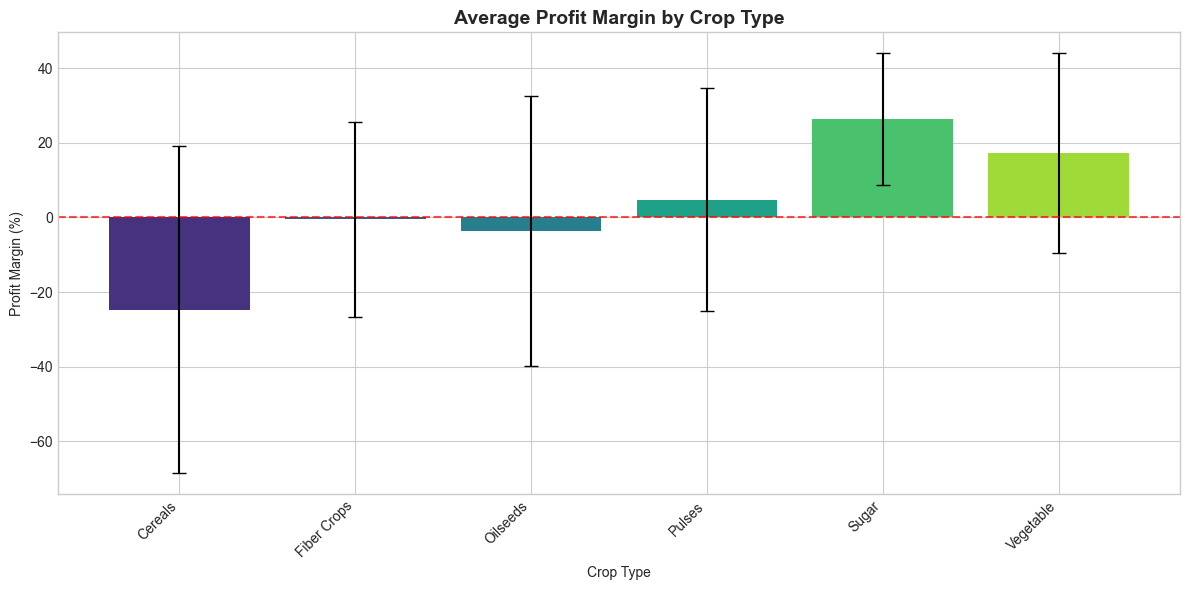

In [9]:
# Visualize profit margins by crop type
fig, ax = plt.subplots(figsize=(12, 6))

crop_type_profit = coc.groupby('crop_type')['profit_margin'].agg(['mean', 'std']).reset_index()
colors = sns.color_palette('viridis', len(crop_type_profit))

bars = ax.bar(crop_type_profit['crop_type'], crop_type_profit['mean'], 
              yerr=crop_type_profit['std'], capsize=5, color=colors)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax.set_title('Average Profit Margin by Crop Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop Type')
ax.set_ylabel('Profit Margin (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/profit_by_crop_type.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Daily Retail Prices

In [10]:
# Large file - sample first
retail_prices = load_dataset('daily-retail-prices-of-essential-commodities.csv', nrows=500000)
dataset_summary(retail_prices, 'Daily Retail Prices (Sample)')

Loaded first 500,000 rows from daily-retail-prices-of-essential-commodities.csv

📊 Daily Retail Prices (Sample)
Shape: 500,000 rows × 6 columns

Columns: ['id', 'date', 'state_name', 'state_code', 'commodity', 'price']

Data Types:
object     3
int64      2
float64    1
Name: count, dtype: int64

Missing Values:
       missing  percent
price    19668      3.9

Sample Data:


,id,date,state_name,state_code,commodity,price
0,0,2015-01-01,Andhra Pradesh,28,Rice,26.0
1,1,2015-01-01,Assam,18,Rice,24.0
2,2,2015-01-01,Bihar,10,Rice,NaN
3,3,2015-01-01,Chandigarh,4,Rice,29.0
4,4,2015-01-01,Chhattisgarh,22,Rice,26.0


,id,date,state_name,state_code,commodity,price
0,0,2015-01-01,Andhra Pradesh,28,Rice,26.00
1,1,2015-01-01,Assam,18,Rice,24.00
2,2,2015-01-01,Bihar,10,Rice,NaN
3,3,2015-01-01,Chandigarh,4,Rice,29.00
4,4,2015-01-01,Chhattisgarh,22,Rice,26.00
...,...,...,...,...,...,...
499995,499995,2019-01-09,Andhra Pradesh,28,Rice,32.00
499996,499996,2019-01-09,Arunachal Pradesh,12,Rice,34.00
499997,499997,2019-01-09,Assam,18,Rice,30.00
499998,499998,2019-01-09,Bihar,10,Rice,30.83


In [11]:
# Commodities available
print("Commodities in dataset:")
print(retail_prices['commodity'].unique())

Commodities in dataset:
['Rice' 'Wheat' 'Atta (Wheat)' 'Gram Dal' 'Tur/Arhar Dal' 'Urad Dal'
 'Moong Dal' 'Masoor Dal' 'Sugar' 'Milk' 'Groundnut Oil (Packed)'
 'Mustard Oil (Packed)' 'Vanaspati (Packed)' 'Soya Oil (Packed)'
 'Sunflower Oil (Packed)' 'Palm Oil (Packed)' 'Gur' 'Tea Loose'
 'Salt Pack (Iodised)' 'Potato' 'Onion' 'Tomato']


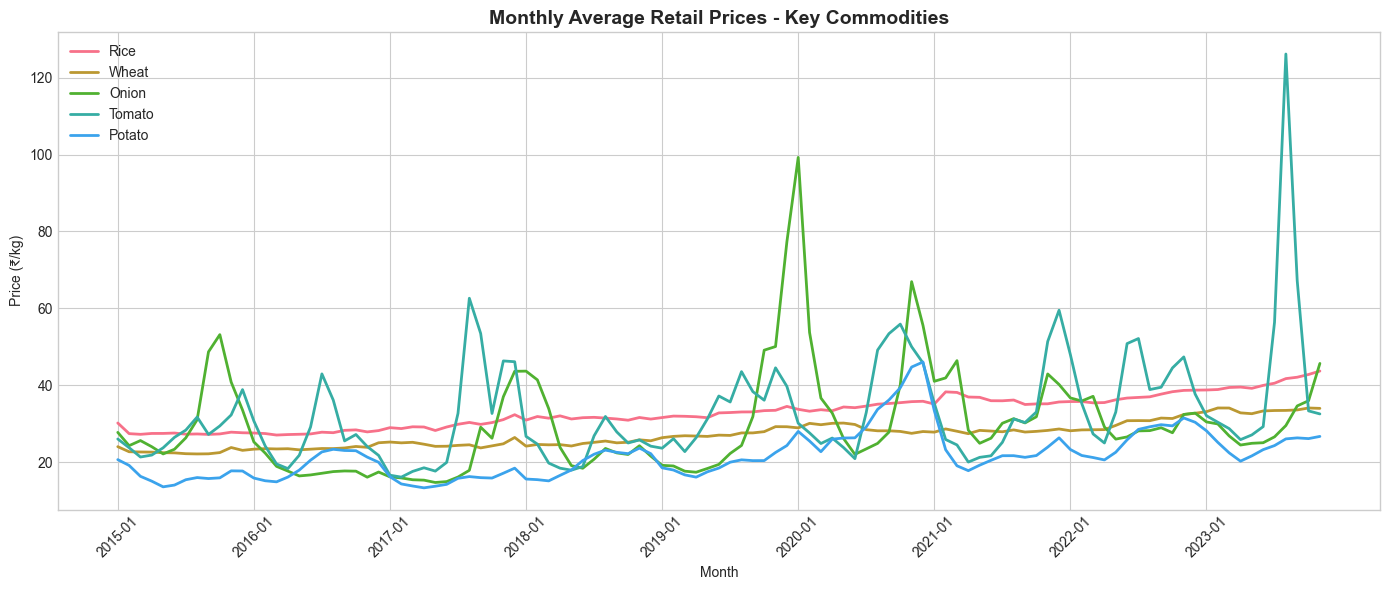

In [12]:
# Price trends for key commodities
retail_prices['date'] = pd.to_datetime(retail_prices['date'])
retail_prices['year_month'] = retail_prices['date'].dt.to_period('M')

key_commodities = ['Rice', 'Wheat', 'Onion', 'Tomato', 'Potato']
monthly_avg = retail_prices[retail_prices['commodity'].isin(key_commodities)].groupby(
    ['year_month', 'commodity'])['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for commodity in key_commodities:
    data = monthly_avg[monthly_avg['commodity'] == commodity]
    ax.plot(data['year_month'].astype(str), data['price'], label=commodity, linewidth=2)

ax.set_title('Monthly Average Retail Prices - Key Commodities', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Price (₹/kg)')
ax.legend()
# Show every 12th label for readability
ax.set_xticks(ax.get_xticks()[::12])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visualizations/retail_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. CLIMATE & WATER DATA

### 4.1 State-level Rainfall

In [13]:
rainfall_state = load_dataset('daily-rainfall-at-state-level.csv', parse_dates=['date'])
dataset_summary(rainfall_state, 'State-level Rainfall')

Loaded 204,876 rows from daily-rainfall-at-state-level.csv

📊 State-level Rainfall
Shape: 204,876 rows × 8 columns

Columns: ['id', 'date', 'state_code', 'state_name', 'actual', 'rfs', 'normal', 'deviation']

Data Types:
float64           4
int64             2
datetime64[ns]    1
object            1
Name: count, dtype: int64

Missing Values:
           missing  percent
actual       17162      8.4
rfs           5865      2.9
normal       11518      5.6
deviation    31021     15.1

Sample Data:


,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0


,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0
...,...,...,...,...,...,...,...,...
204871,204871,2024-07-27,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.40,NaN
204872,204872,2024-07-28,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,8.30,NaN
204873,204873,2024-07-29,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,5.40,NaN
204874,204874,2024-07-30,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.30,NaN


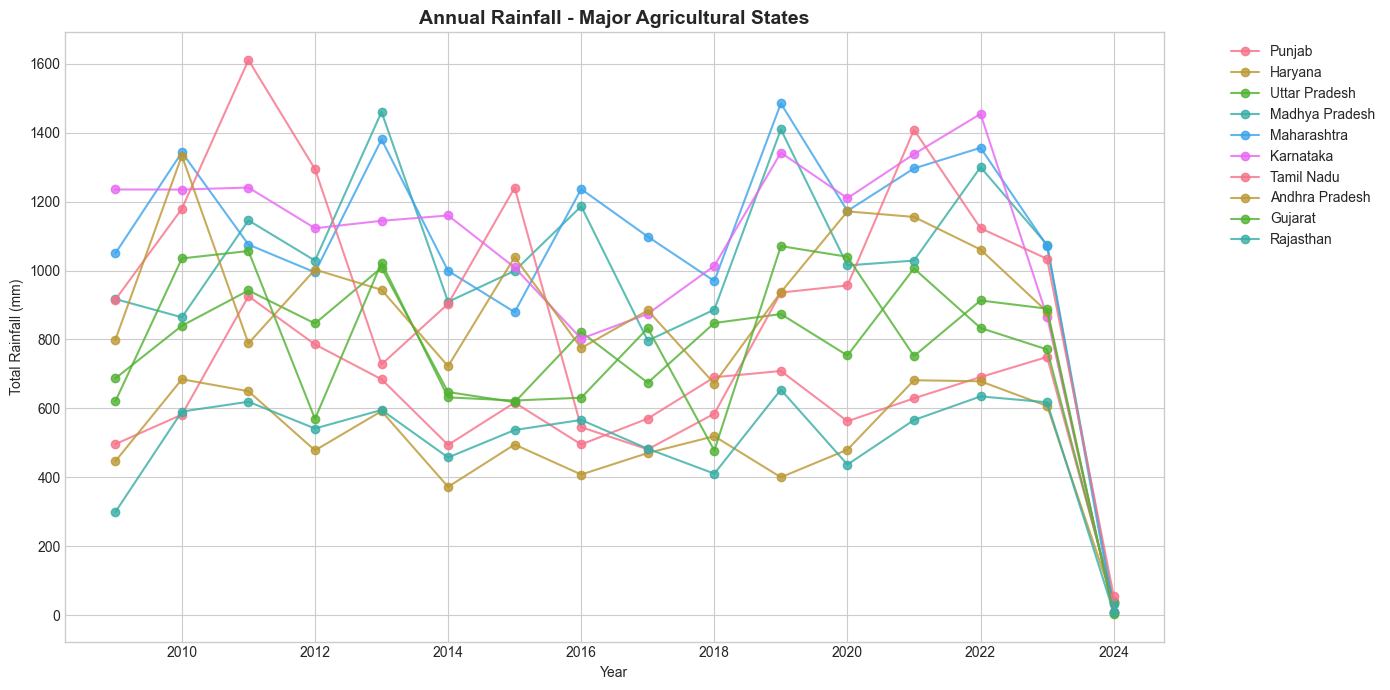

In [14]:
# Annual rainfall analysis
rainfall_state['year'] = rainfall_state['date'].dt.year

# Annual totals by state
annual_rainfall = rainfall_state.groupby(['year', 'state_name'])['actual'].sum().reset_index()

# Focus on major agricultural states
agri_states = ['Punjab', 'Haryana', 'Uttar Pradesh', 'Madhya Pradesh', 'Maharashtra', 
               'Karnataka', 'Tamil Nadu', 'Andhra Pradesh', 'Gujarat', 'Rajasthan']

fig, ax = plt.subplots(figsize=(14, 7))
for state in agri_states:
    data = annual_rainfall[annual_rainfall['state_name'] == state]
    ax.plot(data['year'], data['actual'], marker='o', label=state, alpha=0.8)

ax.set_title('Annual Rainfall - Major Agricultural States', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Rainfall (mm)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visualizations/annual_rainfall_states.png', dpi=150, bbox_inches='tight')
plt.show()

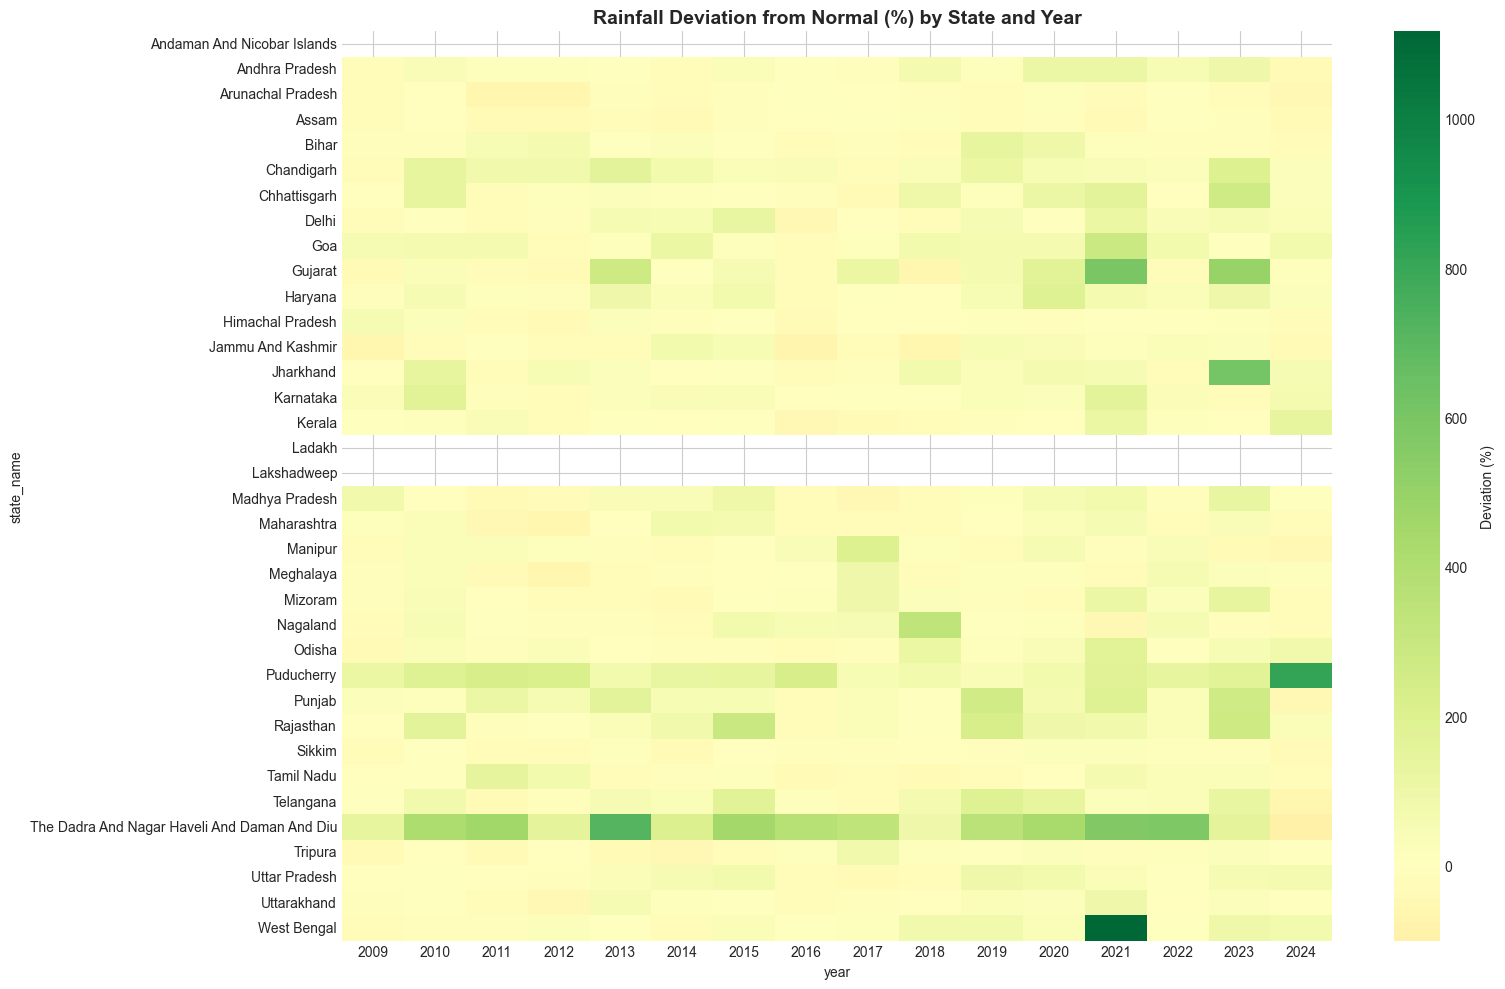

In [15]:
# Rainfall deviation analysis (drought/excess years)
deviation_annual = rainfall_state.groupby(['year', 'state_name'])['deviation'].mean().reset_index()

# Heatmap of deviations
pivot_deviation = deviation_annual.pivot(index='state_name', columns='year', values='deviation')

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_deviation, cmap='RdYlGn', center=0, annot=False, 
            fmt='.0f', ax=ax, cbar_kws={'label': 'Deviation (%)'})
ax.set_title('Rainfall Deviation from Normal (%) by State and Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/rainfall_deviation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Groundwater Levels

In [16]:
# Large file - sample
groundwater = load_dataset('cgwb-changes-in-depth-to-water-level.csv', nrows=200000, parse_dates=['date'])
dataset_summary(groundwater, 'Groundwater Levels (Sample)')

Loaded first 200,000 rows from cgwb-changes-in-depth-to-water-level.csv

📊 Groundwater Levels (Sample)
Shape: 200,000 rows × 14 columns

Columns: ['id', 'date', 'state_name', 'state_code', 'district_name', 'district_code', 'station_name', 'latitude', 'longitude', 'basin', 'sub_basin', 'source', 'currentlevel', 'level_diff']

Data Types:
object            6
float64           4
int64             3
datetime64[ns]    1
Name: count, dtype: int64

Missing Values:
Empty DataFrame
Columns: [missing, percent]
Index: []

Sample Data:


,id,date,state_name,state_code,district_name,district_code,station_name,latitude,longitude,basin,sub_basin,source,currentlevel,level_diff
0,0,2013-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.10,-1.03
1,1,2014-05-14,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.60,2.50
2,2,2014-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.35,-2.25
3,3,2015-05-14,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.52,2.17
4,4,2015-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.69,-1.83


,id,date,state_name,state_code,district_name,district_code,station_name,latitude,longitude,basin,sub_basin,source,currentlevel,level_diff
0,0,2013-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.10,-1.03
1,1,2014-05-14,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.60,2.50
2,2,2014-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.35,-2.25
3,3,2015-05-14,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.52,2.17
4,4,2015-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.69,-1.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199995,2013-08-24,Uttar Pradesh,9,Ghazipur,146,Pyrepur,25.67500,83.24167,Ganga,Ghaghara Confluence To Gomti Confluence,CGWB,5.56,0.68
199996,199996,2013-11-04,Uttar Pradesh,9,Ghazipur,146,Pyrepur,25.67500,83.24167,Ganga,Ghaghara Confluence To Gomti Confluence,CGWB,1.00,-4.56
199997,199997,2014-01-04,Uttar Pradesh,9,Ghazipur,146,Pyrepur,25.67500,83.24167,Ganga,Ghaghara Confluence To Gomti Confluence,CGWB,1.60,0.60
199998,199998,2014-05-14,Uttar Pradesh,9,Ghazipur,146,Pyrepur,25.67500,83.24167,Ganga,Ghaghara Confluence To Gomti Confluence,CGWB,2.91,1.31


In [17]:
# Average water level by state
state_groundwater = groundwater.groupby('state_name').agg({
    'currentlevel': 'mean',
    'level_diff': 'mean'
}).round(2).sort_values('currentlevel', ascending=False)

print("Average Groundwater Depth by State (meters below ground):")
display(state_groundwater.head(15))

Average Groundwater Depth by State (meters below ground):


,currentlevel,level_diff
state_name,,
Punjab,16.11,0.12
Tamil Nadu,10.72,-0.03
West Bengal,8.54,0.04
Uttar Pradesh,7.19,0.05
Andhra Pradesh,5.24,-0.05
Tripura,5.01,-0.04
Bihar,4.26,-0.01
Odisha,3.38,-0.01
Andaman And Nicobar Islands,1.67,0.05


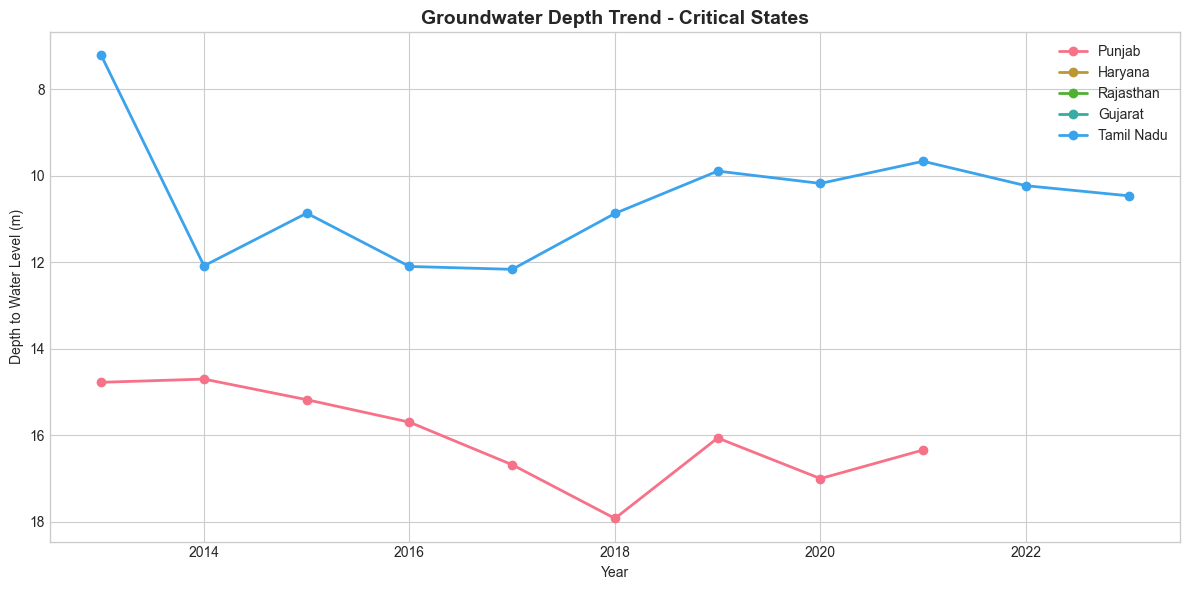

In [18]:
# Groundwater trends over time
groundwater['year'] = groundwater['date'].dt.year
yearly_gw = groundwater.groupby(['year', 'state_name'])['currentlevel'].mean().reset_index()

# States with declining water tables
critical_states = ['Punjab', 'Haryana', 'Rajasthan', 'Gujarat', 'Tamil Nadu']

fig, ax = plt.subplots(figsize=(12, 6))
for state in critical_states:
    data = yearly_gw[yearly_gw['state_name'] == state]
    ax.plot(data['year'], data['currentlevel'], marker='o', label=state, linewidth=2)

ax.set_title('Groundwater Depth Trend - Critical States', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Depth to Water Level (m)')
ax.invert_yaxis()  # Deeper = more critical
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/groundwater_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Climate Vulnerability Indicators

In [19]:
vulnerability = load_dataset('climate-vulnerability-indicators-state-wise.csv')
dataset_summary(vulnerability, 'Climate Vulnerability (State-wise)')

Loaded 36 rows from climate-vulnerability-indicators-state-wise.csv

📊 Climate Vulnerability (State-wise)
Shape: 36 rows × 29 columns

Columns: ['id', 'year', 'state_name', 'state_code', 'climate_vul_in', 'geo_land_area', 'forest_land_area', 'agri_land_area', 'waste_land_area', 'irrigated_area', 'population_density', 'literacy_rate', 'gdp_const_price', 'households_below_poverty', 'infant_mortality', 'poverty_rate', 'income_from_natural_resources', 'out_peren_trees_to_total_agri_out', 'mar_small_op_land_holding', 'yield_variability', 'area_under_pmfby_wbcis', 'rainfed_agriculture', 'forest_land_area_per_population', 'women_workforce', 'employed_under_mgnrega', 'road_rail_density', 'health_workers_per_population', 'vector_diseases_per_population', 'water_diseases_per_population']

Data Types:
float64    25
int64       2
object      2
Name: count, dtype: int64

Missing Values:
                                   missing  percent
climate_vul_in                           6     16.7
geo_land_

,id,year,state_name,state_code,climate_vul_in,geo_land_area,forest_land_area,agri_land_area,waste_land_area,irrigated_area,population_density,literacy_rate,gdp_const_price,households_below_poverty,infant_mortality,poverty_rate,income_from_natural_resources,out_peren_trees_to_total_agri_out,mar_small_op_land_holding,yield_variability,area_under_pmfby_wbcis,rainfed_agriculture,forest_land_area_per_population,women_workforce,employed_under_mgnrega,road_rail_density,health_workers_per_population,vector_diseases_per_population,water_diseases_per_population
0,0,2019-01-01,Andaman And Nicobar Islands,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2019-01-01,Andhra Pradesh,28,0.510,162970.0,29137.0,9047.0,23982.0,46.94,308.0,67.02,4.42,9.20,34.0,9.20,0.31,0.11,0.89,0.08,0.35,0.53,0.77,36.16,47.0,1.11,212.7,0.20,25.13
2,2,2019-01-01,Arunachal Pradesh,12,0.594,83743.0,66688.0,423.0,13906.0,24.89,17.0,65.39,0.14,34.67,36.0,34.67,0.44,0.19,0.45,0.18,0.00,0.75,55.88,35.44,14.0,0.51,270.3,0.73,16.42
3,3,2019-01-01,Assam,18,0.620,78438.0,28327.0,3364.0,9003.0,10.47,398.0,72.19,1.67,31.98,44.0,31.98,0.26,0.09,0.86,0.15,0.02,0.90,0.94,22.46,22.0,4.31,148.5,0.17,7.16
4,4,2019-01-01,Bihar,10,0.614,94163.0,7306.0,6579.0,7685.0,56.59,1106.0,61.80,3.05,33.74,38.0,33.74,0.27,0.08,0.97,0.20,0.40,0.43,0.07,19.07,34.0,2.23,110.2,0.06,3.31


,id,year,state_name,state_code,climate_vul_in,geo_land_area,forest_land_area,agri_land_area,waste_land_area,irrigated_area,population_density,literacy_rate,gdp_const_price,households_below_poverty,infant_mortality,poverty_rate,income_from_natural_resources,out_peren_trees_to_total_agri_out,mar_small_op_land_holding,yield_variability,area_under_pmfby_wbcis,rainfed_agriculture,forest_land_area_per_population,women_workforce,employed_under_mgnrega,road_rail_density,health_workers_per_population,vector_diseases_per_population,water_diseases_per_population
0,0,2019-01-01,Andaman And Nicobar Islands,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2019-01-01,Andhra Pradesh,28,0.510,162970.00,29137.0000,9047.00000,23982.000,46.94,308.000000,67.02,4.42000,9.20,34.0,9.20,0.31,0.11,0.89,0.08,0.35,0.53,0.770000,36.16,47.0,1.11,212.7,0.20,25.13
2,2,2019-01-01,Arunachal Pradesh,12,0.594,83743.00,66688.0000,423.00000,13906.000,24.89,17.000000,65.39,0.14000,34.67,36.0,34.67,0.44,0.19,0.45,0.18,0.00,0.75,55.880000,35.44,14.0,0.51,270.3,0.73,16.42
3,3,2019-01-01,Assam,18,0.620,78438.00,28327.0000,3364.00000,9003.000,10.47,398.000000,72.19,1.67000,31.98,44.0,31.98,0.26,0.09,0.86,0.15,0.02,0.90,0.940000,22.46,22.0,4.31,148.5,0.17,7.16
4,4,2019-01-01,Bihar,10,0.614,94163.00,7306.0000,6579.00000,7685.000,56.59,1106.000000,61.80,3.05000,33.74,38.0,33.74,0.27,0.08,0.97,0.20,0.40,0.43,0.070000,19.07,34.0,2.23,110.2,0.06,3.31
5,5,2019-01-01,Chandigarh,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,2019-01-01,Chhattisgarh,22,0.623,135192.00,55611.0000,5558.00000,10875.000,31.32,189.000000,70.28,1.96000,39.93,39.0,39.93,0.21,0.06,0.83,0.16,0.48,0.69,2.500000,39.70,32.0,0.72,165.3,2.75,6.90
7,7,2019-01-01,Delhi,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,2019-01-01,Goa,30,0.434,3702.00,2237.0000,197.00000,516.000,30.23,394.000000,88.70,0.35000,5.09,8.0,5.09,0.07,0.15,0.91,0.08,0.00,0.70,3.780000,21.92,23.0,6.09,446.8,0.76,15.39
9,9,2019-01-01,Gujarat,24,0.562,196244.00,14857.0000,12661.00000,21740.000,41.09,308.000000,78.03,7.92000,16.63,30.0,16.63,0.19,0.06,0.68,0.13,0.26,0.59,0.400000,23.38,35.0,0.92,174.6,0.61,12.12


In [20]:
# Vulnerability index ranking
vuln_ranking = vulnerability[['state_name', 'climate_vul_in', 'yield_variability', 
                               'rainfed_agriculture', 'irrigated_area', 'poverty_rate']].dropna()

vuln_ranking = vuln_ranking.sort_values('climate_vul_in', ascending=False)
print("Climate Vulnerability Index - State Ranking (Higher = More Vulnerable):")
display(vuln_ranking.head(15))

Climate Vulnerability Index - State Ranking (Higher = More Vulnerable):


,state_name,climate_vul_in,yield_variability,rainfed_agriculture,irrigated_area,poverty_rate
13,Jharkhand,0.674,0.18,0.85,14.95,36.96
22,Mizoram,0.645,0.36,0.89,11.03,20.40
24,Odisha,0.633,0.10,0.72,28.14,32.59
6,Chhattisgarh,0.623,0.16,0.69,31.32,39.93
3,Assam,0.620,0.15,0.90,10.47,31.98
4,Bihar,0.614,0.20,0.43,56.59,33.74
2,Arunachal Pradesh,0.594,0.18,0.75,24.89,34.67
35,West Bengal,0.592,0.10,0.41,59.22,19.98
33,Uttar Pradesh,0.582,0.08,0.13,86.69,29.43
32,Tripura,0.571,0.07,0.69,30.98,14.05


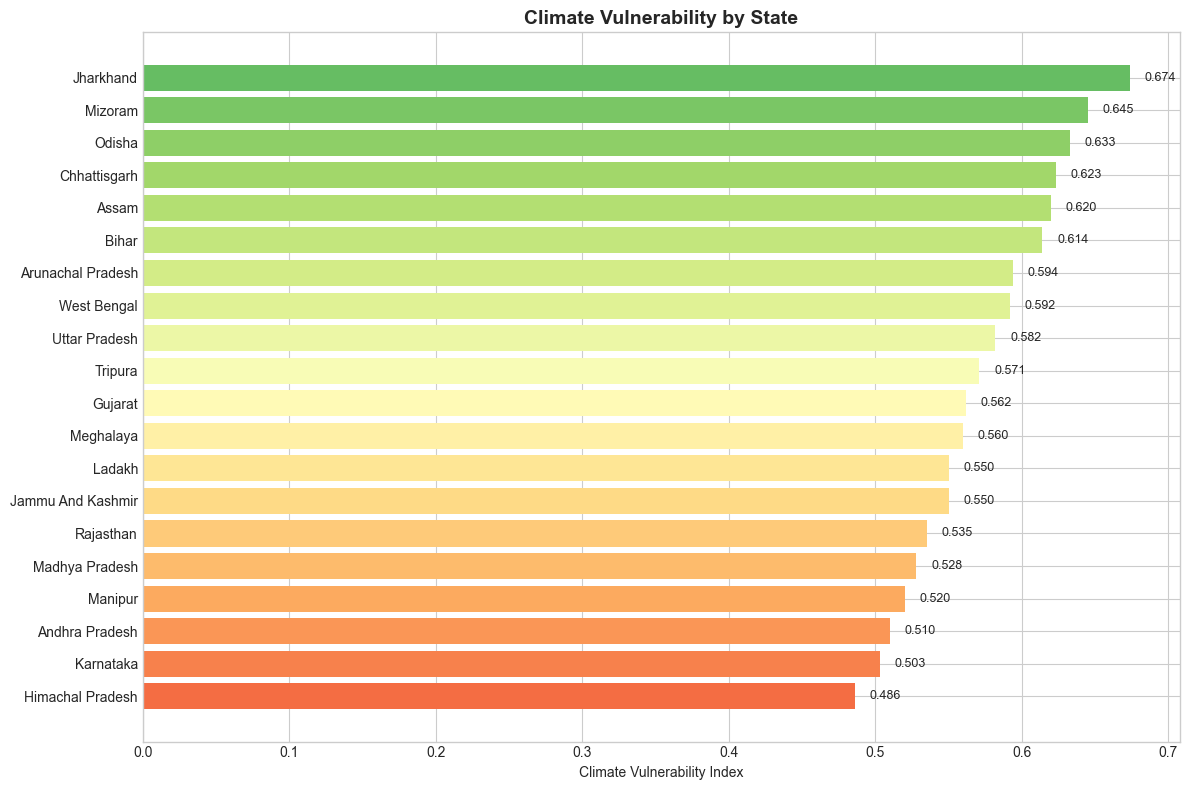

In [21]:
# Vulnerability visualization
fig, ax = plt.subplots(figsize=(12, 8))

vuln_plot = vuln_ranking.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(vuln_plot)))

bars = ax.barh(vuln_plot['state_name'], vuln_plot['climate_vul_in'], color=colors)
ax.set_xlabel('Climate Vulnerability Index')
ax.set_title('Climate Vulnerability by State', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, vuln_plot['climate_vul_in']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visualizations/vulnerability_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. AGRICULTURE PRODUCTION DATA

### 5.1 District-level Crop Census

In [22]:
# Large file - sample
crop_census = load_dataset('district-level-agcensus-crop.csv', nrows=300000)
dataset_summary(crop_census, 'Crop Census (Sample)')

Loaded first 300,000 rows from district-level-agcensus-crop.csv

📊 Crop Census (Sample)
Shape: 300,000 rows × 16 columns

Columns: ['id', 'year', 'state_name', 'state_code', 'district_name', 'district_code', 'social_group', 'farm_size_class', 'farm_size_category', 'crop_name', 'crop_code', 'crop_type', 'hold_no_district', 'irr_ar_district', 'unirr_ar_district', 'total_ar_district']

Data Types:
object     8
int64      4
float64    4
Name: count, dtype: int64

Missing Values:
Empty DataFrame
Columns: [missing, percent]
Index: []

Sample Data:


,id,year,state_name,state_code,district_name,district_code,social_group,farm_size_class,farm_size_category,crop_name,crop_code,crop_type,hold_no_district,irr_ar_district,unirr_ar_district,total_ar_district
0,0,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,< 0.5,Marginal,Paddy,101,Cereals,0.0,0.0,0.0,0.0
1,1,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,0.5-1.0,Marginal,Paddy,101,Cereals,0.0,0.0,0.0,0.0
2,2,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,1.0-2.0,Small,Paddy,101,Cereals,0.0,0.0,0.0,0.0
3,3,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,2.0-3.0,Semi-Medium,Paddy,101,Cereals,0.0,0.0,0.0,0.0
4,4,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,3.0-4.0,Semi-Medium,Paddy,101,Cereals,0.0,0.0,0.0,0.0


,id,year,state_name,state_code,district_name,district_code,social_group,farm_size_class,farm_size_category,crop_name,crop_code,crop_type,hold_no_district,irr_ar_district,unirr_ar_district,total_ar_district
0,0,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,< 0.5,Marginal,Paddy,101,Cereals,0.0,0.0,0.00,0.00
1,1,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,0.5-1.0,Marginal,Paddy,101,Cereals,0.0,0.0,0.00,0.00
2,2,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,1.0-2.0,Small,Paddy,101,Cereals,0.0,0.0,0.00,0.00
3,3,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,2.0-3.0,Semi-Medium,Paddy,101,Cereals,0.0,0.0,0.00,0.00
4,4,2010-11,Andaman And Nicobar Islands,35,Nicobars,603,Institutional,3.0-4.0,Semi-Medium,Paddy,101,Cereals,0.0,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,2010-11,Karnataka,29,Mysuru,545,Scheduled Caste,4.0-5.0,Medium,Tur (Arhar),202,Pulses,7.0,0.0,1.85,1.85
299996,299996,2010-11,Karnataka,29,Mysuru,545,Scheduled Caste,5.0-7.5,Medium,Tur (Arhar),202,Pulses,0.0,0.0,0.00,0.00
299997,299997,2010-11,Karnataka,29,Mysuru,545,Scheduled Caste,7.5-10.0,Medium,Tur (Arhar),202,Pulses,4.0,0.0,3.37,3.37
299998,299998,2010-11,Karnataka,29,Mysuru,545,Scheduled Caste,10.0-20.0,Large,Tur (Arhar),202,Pulses,0.0,0.0,0.00,0.00


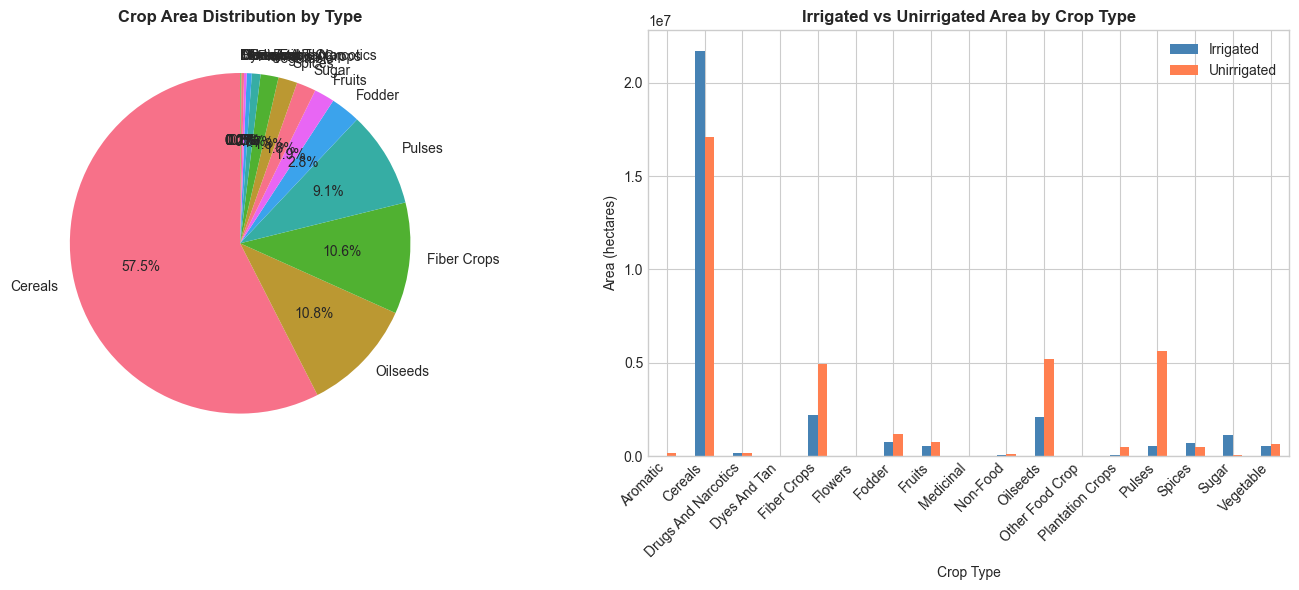

In [23]:
# Crop type distribution
crop_area = crop_census.groupby('crop_type')['total_ar_district'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(crop_area.values, labels=crop_area.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Crop Area Distribution by Type', fontsize=12, fontweight='bold')

# Irrigated vs Unirrigated
irrigation = crop_census.groupby('crop_type')[['irr_ar_district', 'unirr_ar_district']].sum()
irrigation.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Irrigated vs Unirrigated Area by Crop Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Crop Type')
axes[1].set_ylabel('Area (hectares)')
axes[1].legend(['Irrigated', 'Unirrigated'])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../visualizations/crop_census_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Horticulture Production (NHB)

In [24]:
horticulture = load_dataset('area-and-production-statistics-nhb.csv')
dataset_summary(horticulture, 'Horticulture Production')

Loaded 1,270 rows from area-and-production-statistics-nhb.csv

📊 Horticulture Production
Shape: 1,270 rows × 7 columns

Columns: ['id', 'year', 'state_name', 'state_code', 'crop_category', 'area', 'production']

Data Types:
object     3
int64      2
float64    2
Name: count, dtype: int64

Missing Values:
Empty DataFrame
Columns: [missing, percent]
Index: []

Sample Data:


,id,year,state_name,state_code,crop_category,area,production
0,0,2018-19,Andhra Pradesh,28,Fruits,718910.0,1.761470e+13
1,1,2018-19,Arunachal Pradesh,12,Fruits,48140.0,1.258400e+11
2,2,2018-19,Assam,18,Fruits,167200.0,2.518890e+12
3,3,2018-19,Bihar,10,Fruits,313950.0,4.384460e+12
4,4,2018-19,Chhattisgarh,22,Fruits,225240.0,2.580310e+12


,id,year,state_name,state_code,crop_category,area,production
0,0,2018-19,Andhra Pradesh,28,Fruits,718910.0,1.761470e+13
1,1,2018-19,Arunachal Pradesh,12,Fruits,48140.0,1.258400e+11
2,2,2018-19,Assam,18,Fruits,167200.0,2.518890e+12
3,3,2018-19,Bihar,10,Fruits,313950.0,4.384460e+12
4,4,2018-19,Chhattisgarh,22,Fruits,225240.0,2.580310e+12
...,...,...,...,...,...,...,...
1265,1265,2013-14,Telangana,36,Flowers,6890.0,4.068000e+10
1266,1266,2013-14,Tripura,16,Flowers,0.0,5.406000e+10
1267,1267,2013-14,Uttar Pradesh,9,Flowers,16580.0,4.061000e+10
1268,1268,2013-14,Uttrakhand,5,Flowers,1350.0,1.472100e+11


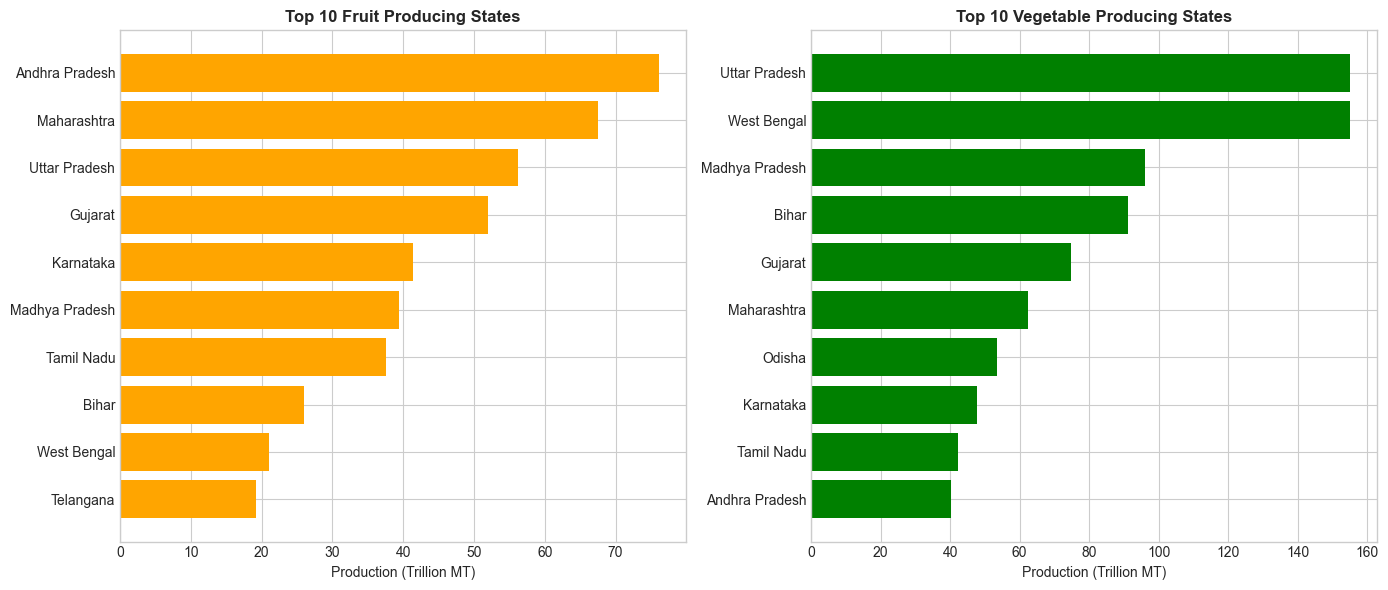

In [25]:
# Top producing states
state_production = horticulture.groupby(['state_name', 'crop_category'])['production'].sum().reset_index()

# Fruits production
fruits = state_production[state_production['crop_category'] == 'Fruits'].nlargest(10, 'production')
vegetables = state_production[state_production['crop_category'] == 'Vegetables'].nlargest(10, 'production')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(fruits['state_name'], fruits['production']/1e12, color='orange')
axes[0].set_title('Top 10 Fruit Producing States', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Production (Trillion MT)')
axes[0].invert_yaxis()

axes[1].barh(vegetables['state_name'], vegetables['production']/1e12, color='green')
axes[1].set_title('Top 10 Vegetable Producing States', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Production (Trillion MT)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../visualizations/horticulture_production.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. EXPORT DATA

In [26]:
# Load sample from each export file
exports_asia = load_dataset('exports-to-asian-countries.csv', nrows=100000, parse_dates=['date'])
exports_europe = load_dataset('exports-to-european-countries.csv', nrows=100000, parse_dates=['date'])
exports_africa = load_dataset('exports-to-african-countries.csv', nrows=100000, parse_dates=['date'])
exports_america = load_dataset('exports-to-american-countries.csv', nrows=100000, parse_dates=['date'])

Loaded first 100,000 rows from exports-to-asian-countries.csv
Loaded first 100,000 rows from exports-to-european-countries.csv
Loaded first 100,000 rows from exports-to-african-countries.csv
Loaded first 100,000 rows from exports-to-american-countries.csv


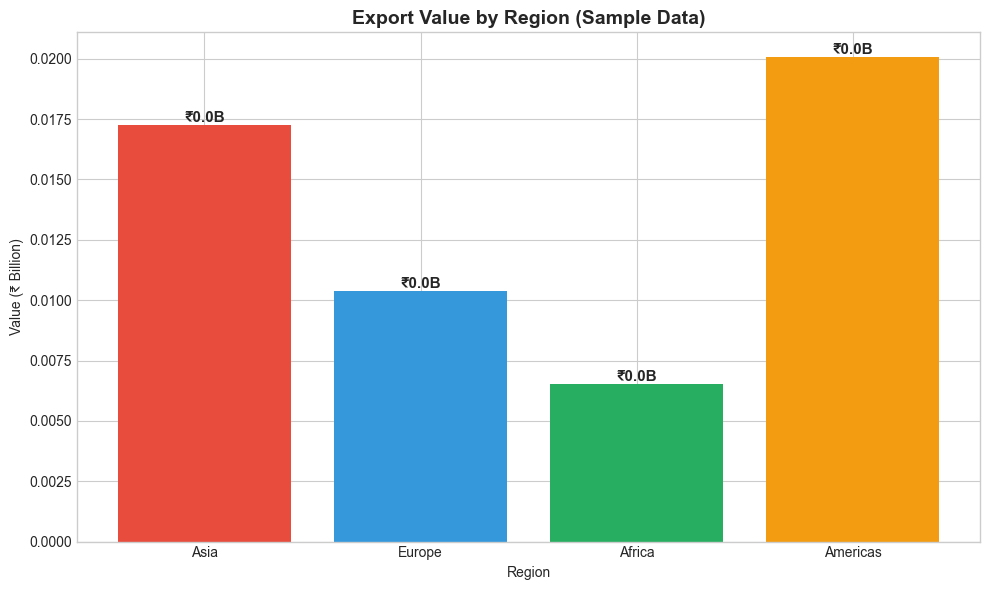

In [27]:
# Export value by region
export_summary = {
    'Asia': exports_asia['value_rs'].sum(),
    'Europe': exports_europe['value_rs'].sum(),
    'Africa': exports_africa['value_rs'].sum(),
    'Americas': exports_america['value_rs'].sum()
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']
bars = ax.bar(export_summary.keys(), [v/1e9 for v in export_summary.values()], color=colors)
ax.set_title('Export Value by Region (Sample Data)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (₹ Billion)')
ax.set_xlabel('Region')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'₹{height:.1f}B',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/export_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

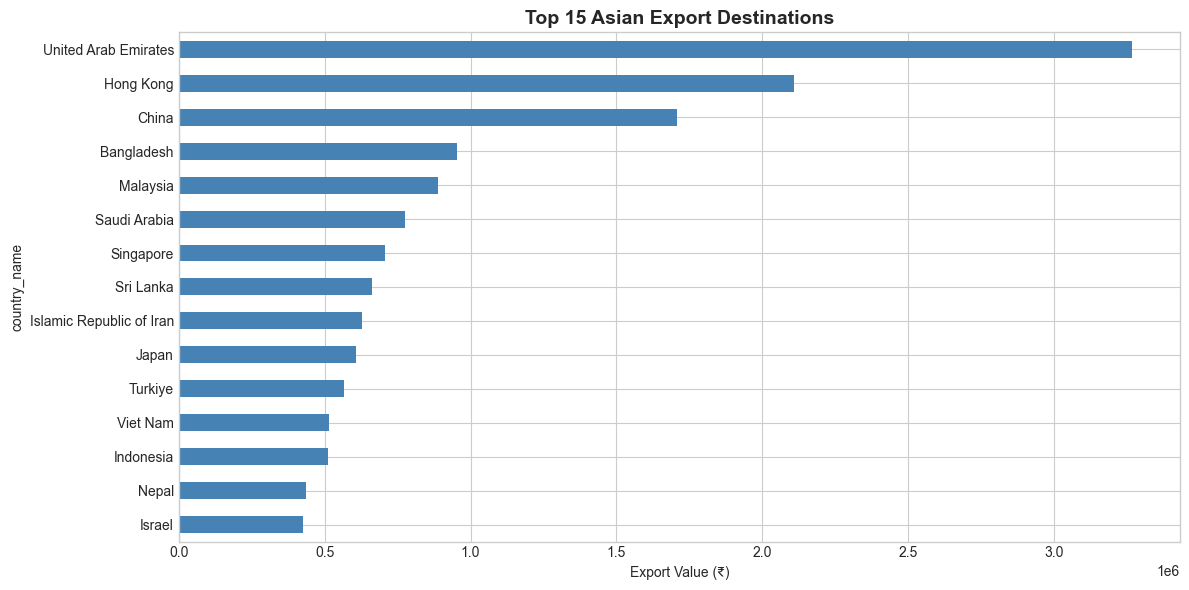

In [28]:
# Top export destinations (Asia)
top_countries = exports_asia.groupby('country_name')['value_rs'].sum().nlargest(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Asian Export Destinations', fontsize=14, fontweight='bold')
ax.set_xlabel('Export Value (₹)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../visualizations/top_asian_exports.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. DATA QUALITY SUMMARY

In [29]:
# Summary of data quality issues
quality_issues = {
    'Dataset': [
        'daily-retail-prices', 'daily-rainfall-state', 'daily-rainfall-district',
        'cost-of-cultivation', 'consumer-price-index', 'climate-vulnerability-district'
    ],
    'Key Issue': [
        'price: 3.8% missing', 'deviation: 15% missing', 'deviation: 32% missing',
        'contractor_pay: 96% missing', 'cpi/inflation: 1% missing', 'Many indicators: 96% missing'
    ],
    'Recommendation': [
        'Interpolate or fill with state median', 'Calculate from actual/normal',
        'Exclude or impute carefully', 'Drop column', 'Forward-fill by group', 'Use only complete indicators'
    ]
}

quality_df = pd.DataFrame(quality_issues)
print("\n📋 DATA QUALITY SUMMARY & RECOMMENDATIONS")
display(quality_df)


📋 DATA QUALITY SUMMARY & RECOMMENDATIONS


,Dataset,Key Issue,Recommendation
0,daily-retail-prices,price: 3.8% missing,Interpolate or fill with state median
1,daily-rainfall-state,deviation: 15% missing,Calculate from actual/normal
2,daily-rainfall-district,deviation: 32% missing,Exclude or impute carefully
3,cost-of-cultivation,contractor_pay: 96% missing,Drop column
4,consumer-price-index,cpi/inflation: 1% missing,Forward-fill by group
5,climate-vulnerability-district,Many indicators: 96% missing,Use only complete indicators


---
## 8. NEXT STEPS

### Recommended Analysis Path:

1. **Data Cleaning** (see `02_data_cleaning.ipynb`)
   - Handle missing values
   - Standardize column names
   - Convert date formats
   - Remove duplicates

2. **Data Integration** (see `03_integration.ipynb`)
   - Merge datasets on common keys
   - Create unified time series
   - Build district-level master dataset

3. **Advanced Analysis**
   - Price-climate correlation
   - Vulnerability index construction
   - Yield prediction models
   - Export trend forecasting

In [30]:
print("\n✅ Data Exploration Complete!")
print(f"\nGenerated visualizations saved to: ../visualizations/")
print("\nProceeed to 02_data_cleaning.ipynb for data preparation.")


✅ Data Exploration Complete!

Generated visualizations saved to: ../visualizations/

Proceeed to 02_data_cleaning.ipynb for data preparation.
